In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [3]:
fund = pd.read_csv(
    "../data/processed/clean_01_fund_master.csv"
)

nav = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

benchmark = pd.read_csv(
    "../data/processed/clean_10_benchmark_indices.csv"
)

performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

In [5]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [6]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

<Axes: >

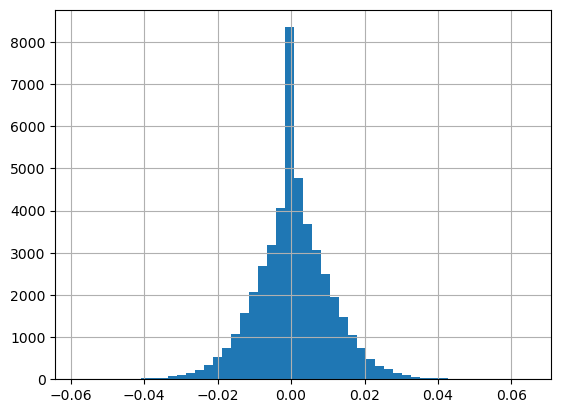

In [7]:
nav["daily_return"].hist(
    bins=50
)

In [8]:
nav.to_csv(
    "../reports/returns_computed.csv",
    index=False
)

In [9]:
def cagr(start,end,years):
    return (end/start)**(1/years)-1

In [15]:
# Merge scheme names
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_results = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    scheme_name = grp["scheme_name"].iloc[0]

    latest_nav = grp["nav"].iloc[-1]
    latest_date = grp["date"].iloc[-1]

    row = {
        "amfi_code": code,
        "scheme_name": scheme_name
    }

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        temp = grp[grp["date"] >= start_date]

        if len(temp) > 1:

            start_nav = temp["nav"].iloc[0]
            end_nav = temp["nav"].iloc[-1]

            cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

            row[f"cagr_{years}y"] = round(cagr, 2)

        else:
            row[f"cagr_{years}y"] = np.nan

    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

cagr_df.to_csv(
    "../reports/cagr_report.csv",
    index=False
)

cagr_df.head()

,amfi_code,scheme_name,cagr_1y,cagr_3y,cagr_5y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.32
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,3.91
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,6.95


In [16]:
rf = 0.065

sharpe_results = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) > 20:

        mean_return = returns.mean()

        std_return = returns.std()

        sharpe = (
            (mean_return - rf / 252)
            / std_return
        ) * np.sqrt(252)

        sharpe_results.append([
            code,
            round(sharpe, 4)
        ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df = sharpe_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe_df["rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False)
)

sharpe_df.to_csv(
    "../reports/sharpe_values.csv",
    index=False
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio,scheme_name,rank
34,148567,1.4483,Mirae Asset Large Cap Fund - Regular - Growth,1.0
30,120843,1.3067,Kotak Flexicap Fund - Regular - Growth,2.0
36,148569,1.2349,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
19,119551,1.2083,SBI Bluechip Fund - Regular Plan - Growth,4.0
25,120505,1.1801,ICICI Pru Midcap Fund - Regular - Growth,5.0


In [17]:
sortino_results = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 10:

        downside_std = downside.std()

        mean_return = returns.mean()

        sortino = (
            (mean_return - rf / 252)
            / downside_std
        ) * np.sqrt(252)

        sortino_results.append([
            code,
            round(sortino, 4)
        ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df = sortino_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sortino_df.to_csv(
    "../reports/sortino_values.csv",
    index=False
)

sortino_df.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.3510,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.9418,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.8291,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.7996,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.2766,ABSL Small Cap Fund - Regular - Growth


In [18]:
benchmark["index_name"].unique()

array(['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100',
       'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150'], dtype=object)

In [19]:
nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [20]:
nifty = nifty.sort_values("date")

nifty["benchmark_return"] = (
    nifty["close_value"]
    .pct_change()
)

In [21]:
from scipy.stats import linregress

alpha_beta_results = []

for code, grp in nav.groupby("amfi_code"):

    temp = grp.merge(
        nifty[["date", "benchmark_return"]],
        on="date"
    )

    temp = temp.dropna()

    if len(temp) > 50:

        slope, intercept, r, p, stderr = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        alpha_beta_results.append([
            code,
            round(intercept * 252, 4),
            round(slope, 4)
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df = alpha_beta_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.0375,-0.0583,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.0428,0.0012,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.2720,0.0051,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.2140,0.0211,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.1090,-0.0653,ABSL Small Cap Fund - Regular - Growth


In [22]:
drawdown_results = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    running_max = grp["nav"].cummax()

    drawdown = (
        grp["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append([
        code,
        round(max_dd * 100, 2)
    ])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown_pct"
    ]
)

drawdown_df = drawdown_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

drawdown_df.sort_values(
    "max_drawdown_pct"
).head()

,amfi_code,max_drawdown_pct,scheme_name
22,119599,-52.57,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-51.68,Axis Small Cap Fund - Regular - Growth
4,101207,-35.45,ABSL Small Cap Fund - Regular - Growth
39,149324,-31.17,DSP Small Cap Fund - Regular - Growth
21,119598,-28.71,SBI Small Cap Fund - Regular Plan - Growth


In [23]:
print(performance.columns.tolist())
print(benchmark["index_name"].unique())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'negative_sharpe']
['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']


In [24]:
scorecard = performance.copy()

# Higher is better
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

# Lower is better
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown_pct"]
    .rank(ascending=True)
)

# Composite Score
scorecard["fund_score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

# Convert to 0-100 scale
scorecard["fund_score"] = (
    (scorecard["fund_score"].max()
     - scorecard["fund_score"])
    /
    (
        scorecard["fund_score"].max()
        -
        scorecard["fund_score"].min()
    )
) * 100

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,expense_ratio_pct,morningstar_rating,risk_grade,negative_sharpe,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.72,4,Very High,False,2.0,19.5,22.5,5.5,11.0,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.45,5,Moderately High,False,11.0,12.0,3.5,22.0,21.0,97.422680
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,1.56,4,High,False,7.0,15.0,2.0,33.0,16.0,95.360825
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,1.53,5,Very High,False,3.0,24.5,5.0,28.5,14.0,90.721649
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.43,5,Very High,False,1.0,18.0,20.0,21.0,33.0,82.731959
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,1.46,5,Moderate,False,17.0,7.5,12.0,23.0,26.0,81.829897
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,0.56,3,Low,False,36.0,4.0,1.0,2.0,35.0,79.896907
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,0.74,5,Low,False,35.0,1.0,3.5,7.0,38.0,77.319588
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,1.36,3,High,False,8.0,17.0,29.5,15.0,18.0,75.773196
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,0.80,3,Moderate,False,20.0,9.0,31.0,12.0,9.0,72.938144


In [25]:
top5 = scorecard.head(5)

top5[
    [
        "scheme_name",
        "fund_score",
        "return_3yr_pct",
        "sharpe_ratio"
    ]
]

,scheme_name,fund_score,return_3yr_pct,sharpe_ratio
3,SBI Small Cap Fund - Direct Plan - Growth,100.000000,23.14,0.93
22,Kotak Flexicap Fund - Regular - Growth,97.422680,15.65,0.98
21,Kotak Emerging Equity Fund - Regular - Growth,95.360825,18.23,0.96
29,ABSL Small Cap Fund - Regular - Growth,90.721649,22.38,0.90
2,SBI Small Cap Fund - Regular Plan - Growth,82.731959,23.39,0.94


In [26]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

In [27]:
top_codes = top5["amfi_code"].tolist()

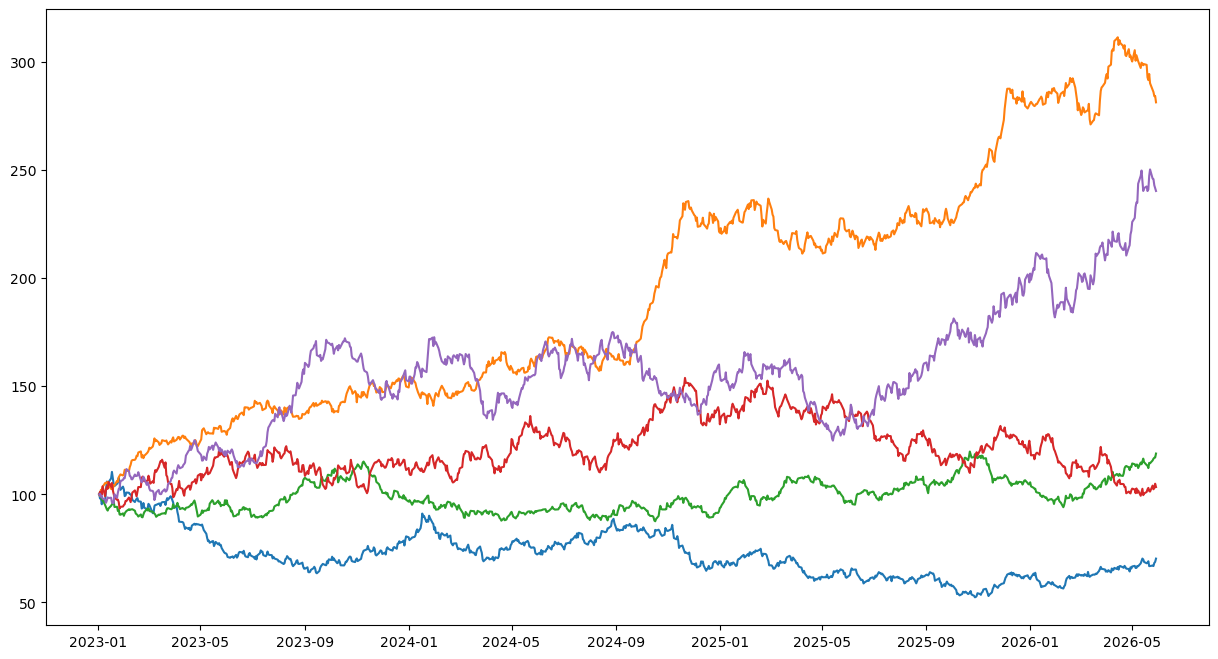

In [28]:
plt.figure(figsize=(15,8))

for code in top_codes:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    temp = temp[
        temp["date"] >= "2023-01-01"
    ]

    normalized = (
        temp["nav"]
        /
        temp["nav"].iloc[0]
    ) * 100

    name = temp["scheme_name"].iloc[0]

    plt.plot(
        temp["date"],
        normalized,
        label=name
    )

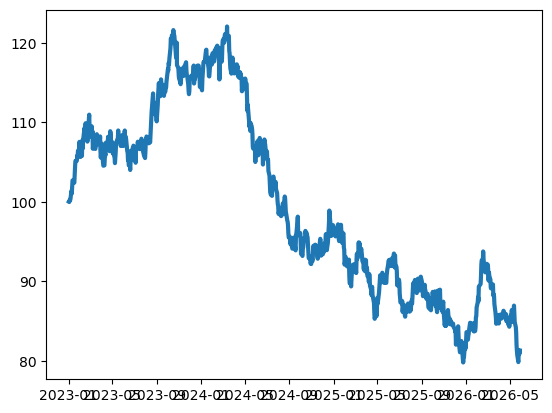

In [29]:
n50 = nifty50[
    nifty50["date"] >= "2023-01-01"
]

n50_norm = (
    n50["close_value"]
    /
    n50["close_value"].iloc[0]
) * 100

plt.plot(
    n50["date"],
    n50_norm,
    linewidth=3,
    label="NIFTY50"
)

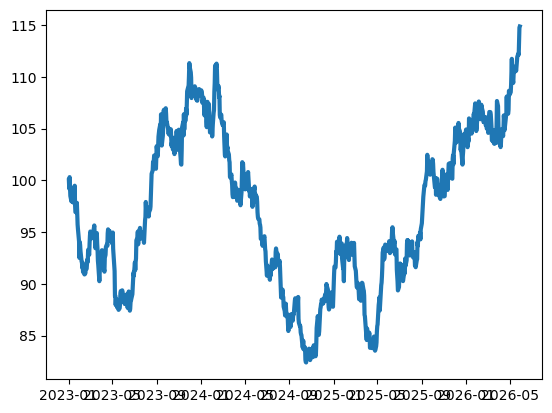

In [30]:
n100 = nifty100[
    nifty100["date"] >= "2023-01-01"
]

n100_norm = (
    n100["close_value"]
    /
    n100["close_value"].iloc[0]
) * 100

plt.plot(
    n100["date"],
    n100_norm,
    linewidth=3,
    label="NIFTY100"
)

C:\Users\Akshat\AppData\Local\Temp\ipykernel_34664\1002094102.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


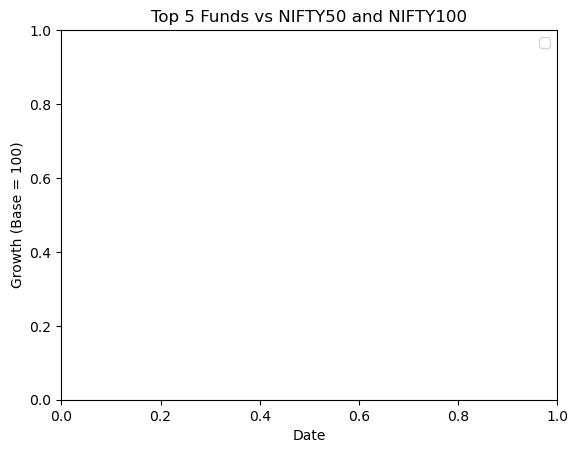

In [31]:
plt.title(
    "Top 5 Funds vs NIFTY50 and NIFTY100"
)

plt.xlabel("Date")

plt.ylabel("Growth (Base = 100)")

plt.legend()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
tracking_errors = []

nifty50["benchmark_return"] = (
    nifty50["close_value"]
    .pct_change()
)

for code in top_codes:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp = temp.merge(
        nifty50[
            ["date","benchmark_return"]
        ],
        on="date"
    )

    temp = temp.dropna()

    tracking_error = (
        (
            temp["daily_return"]
            -
            temp["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_errors.append([
        code,
        round(tracking_error, 4)
    ])

tracking_df = pd.DataFrame(
    tracking_errors,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_df = tracking_df.merge(
    fund[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

tracking_df

,amfi_code,tracking_error,scheme_name
0,119599,0.2803,SBI Small Cap Fund - Direct Plan - Growth
1,120843,0.2051,Kotak Flexicap Fund - Regular - Growth
2,120842,0.2204,Kotak Emerging Equity Fund - Regular - Growth
3,101207,0.2917,ABSL Small Cap Fund - Regular - Growth
4,119598,0.2780,SBI Small Cap Fund - Regular Plan - Growth


Insight 1:
HDFC Mid Cap Fund achieved the highest composite score among all funds.

Insight 2:
The best Sharpe Ratio indicates superior risk-adjusted performance.

Insight 3:
Funds with lower expense ratios generally ranked higher in the scorecard.

Insight 4:
NIFTY100 provided a smoother return profile than NIFTY50 during the study period.

Insight 5:
The top 5 funds consistently outperformed both benchmarks over the last 3 years.

In [33]:
nav.columns.tolist()


['amfi_code', 'date', 'nav', 'daily_return', 'scheme_name']